In [1]:
import pandas as pd
from pathlib import Path

csv_path = Path(
    "/Users/kethandosapati/Developer/personal/arxiv-trend-predictor-001/data/arxiv_data/arxiv_tech_papers_20260210_161210.csv")
print("Using CSV:", csv_path)
df = pd.read_csv(csv_path)

df.shape

Using CSV: /Users/kethandosapati/Developer/personal/arxiv-trend-predictor-001/data/arxiv_data/arxiv_tech_papers_20260210_161210.csv


(36965, 17)

In [4]:
df.head(3)

,arxiv_id,title,abstract,published_date,updated_date,year,month,primary_category,all_categories,tech_domain,authors,author_count,doi,journal_ref,pdf_url,title_length,abstract_length
0,0012020v1,Creativity and Delusions: A Neurocomputational...,Thinking is one of the most interesting mental...,2000-12-22,2000-12-22,2000,12,cs.NE,"cs.NE, cs.AI",Artificial Intelligence,"Daniele Quintella Mendes, Luis Alfredo Vidal d...",2,NaN,NaN,https://arxiv.org/pdf/cs/0012020v1,6,210
1,0012011v1,Towards a Universal Theory of Artificial Intel...,Decision theory formally solves the problem of...,2000-12-16,2000-12-16,2000,12,cs.AI,"cs.AI, cs.CC, cs.IT, cs.LG",Artificial Intelligence,Marcus Hutter,1,NaN,Lecture Notes in Artificial Intelligence (LNAI...,https://arxiv.org/pdf/cs/0012011v1,15,103
2,0012010v1,The Role of Commutativity in Constraint Propag...,Constraint propagation algorithms form an impo...,2000-12-15,2000-12-15,2000,12,cs.PF,"cs.PF, cs.AI",Artificial Intelligence,Krzysztof R. Apt,1,NaN,NaN,https://arxiv.org/pdf/cs/0012010v1,8,128


In [5]:
# how many papers per year / per domain (rough cut)
year_counts = df["year"].value_counts().sort_index()
print("years span:", int(year_counts.index.min()), "->", int(year_counts.index.max()))
print("last 10 years:")
print(year_counts.tail(10))

print("\nTop tech domains:")
print(df["tech_domain"].value_counts().head(10))

years span: 2000 -> 2025
last 10 years:
year
2016    1766
2017    1774
2018    1790
2019    1804
2020    1819
2021    1774
2022    1785
2023    1771
2024    1762
2025    1808
Name: count, dtype: int64

Top tech domains:
tech_domain
Artificial Intelligence           2567
Data Structures & Algorithms      2201
Computational Complexity          1997
Software Engineering              1971
Databases                         1962
Networking                        1867
Programming Languages             1863
Distributed Computing             1850
Cryptography & Security           1843
Neural Networks & Evolutionary    1817
Name: count, dtype: int64


years span: 2000 -> 2025
last 10 years:
year
2016    1766
2017    1774
2018    1790
2019    1804
2020    1819
2021    1774
2022    1785
2023    1771
2024    1762
2025    1808
Name: count, dtype: int64

Top tech domains:
tech_domain
Artificial Intelligence           2567
Data Structures & Algorithms      2201
Computational Complexity          1997
Software Engineering              1971
Databases                         1962
Networking                        1867
Programming Languages             1863
Distributed Computing             1850
Cryptography & Security           1843
Neural Networks & Evolutionary    1817
Name: count, dtype: int64


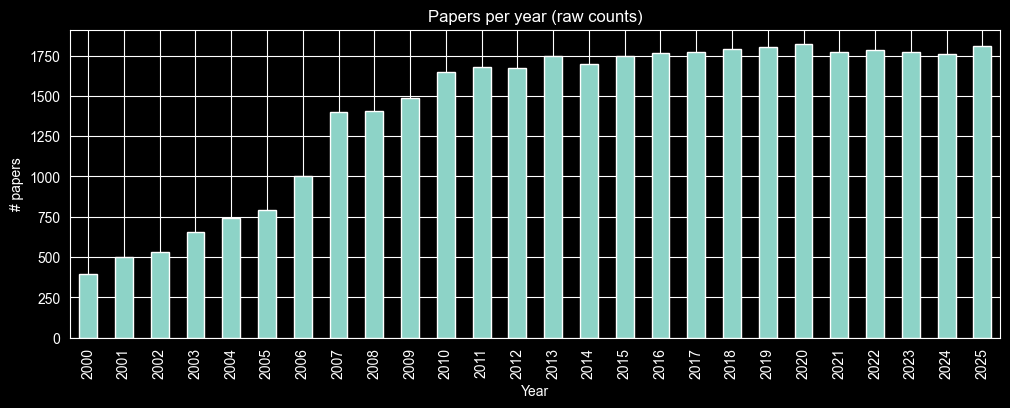

In [6]:
# how many papers per year / per domain (rough cut)
year_counts = df["year"].value_counts().sort_index()
print("years span:", int(year_counts.index.min()), "->", int(year_counts.index.max()))
print("last 10 years:")
print(year_counts.tail(10))

print("\nTop tech domains:")
print(df["tech_domain"].value_counts().head(10))
import matplotlib.pyplot as plt

_ = year_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Papers per year (raw counts)")
plt.xlabel("Year")
plt.ylabel("# papers")
plt.show()

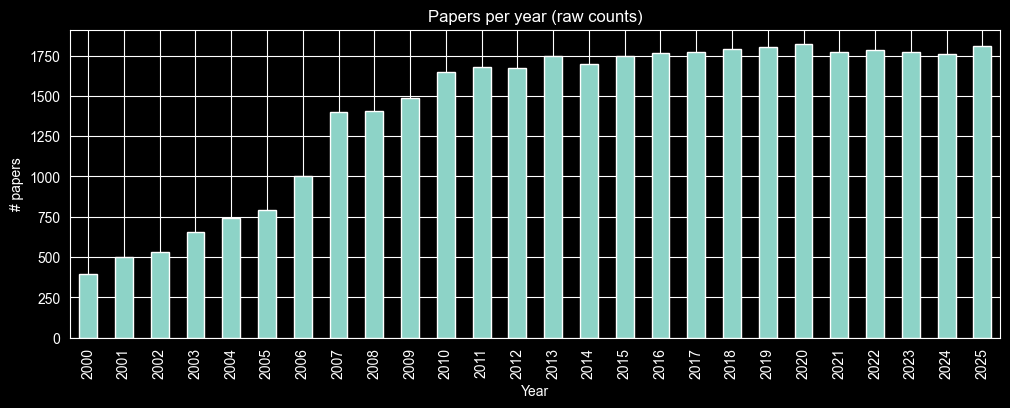

Saving plots to: /Users/kethandosapati/Developer/personal/analysis_output


In [7]:
import matplotlib.pyplot as plt

_ = year_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Papers per year (raw counts)")
plt.xlabel("Year")
plt.ylabel("# papers")
plt.show()
# where to save plots (same folder as notebook, or use project root)
from pathlib import Path

output_dir = Path.cwd().parents[2] / "analysis_output"
output_dir.mkdir(parents=True, exist_ok=True)
print("Saving plots to:", output_dir)

In [12]:
# where to save plots (same folder as notebook, or use project root)
from pathlib import Path

output_dir = Path.cwd().parents[2] / "analysis_output"
output_dir.mkdir(parents=True, exist_ok=True)
print("Saving plots to:", output_dir)

Saving plots to: /Users/kethandosapati/Developer/personal/analysis_output


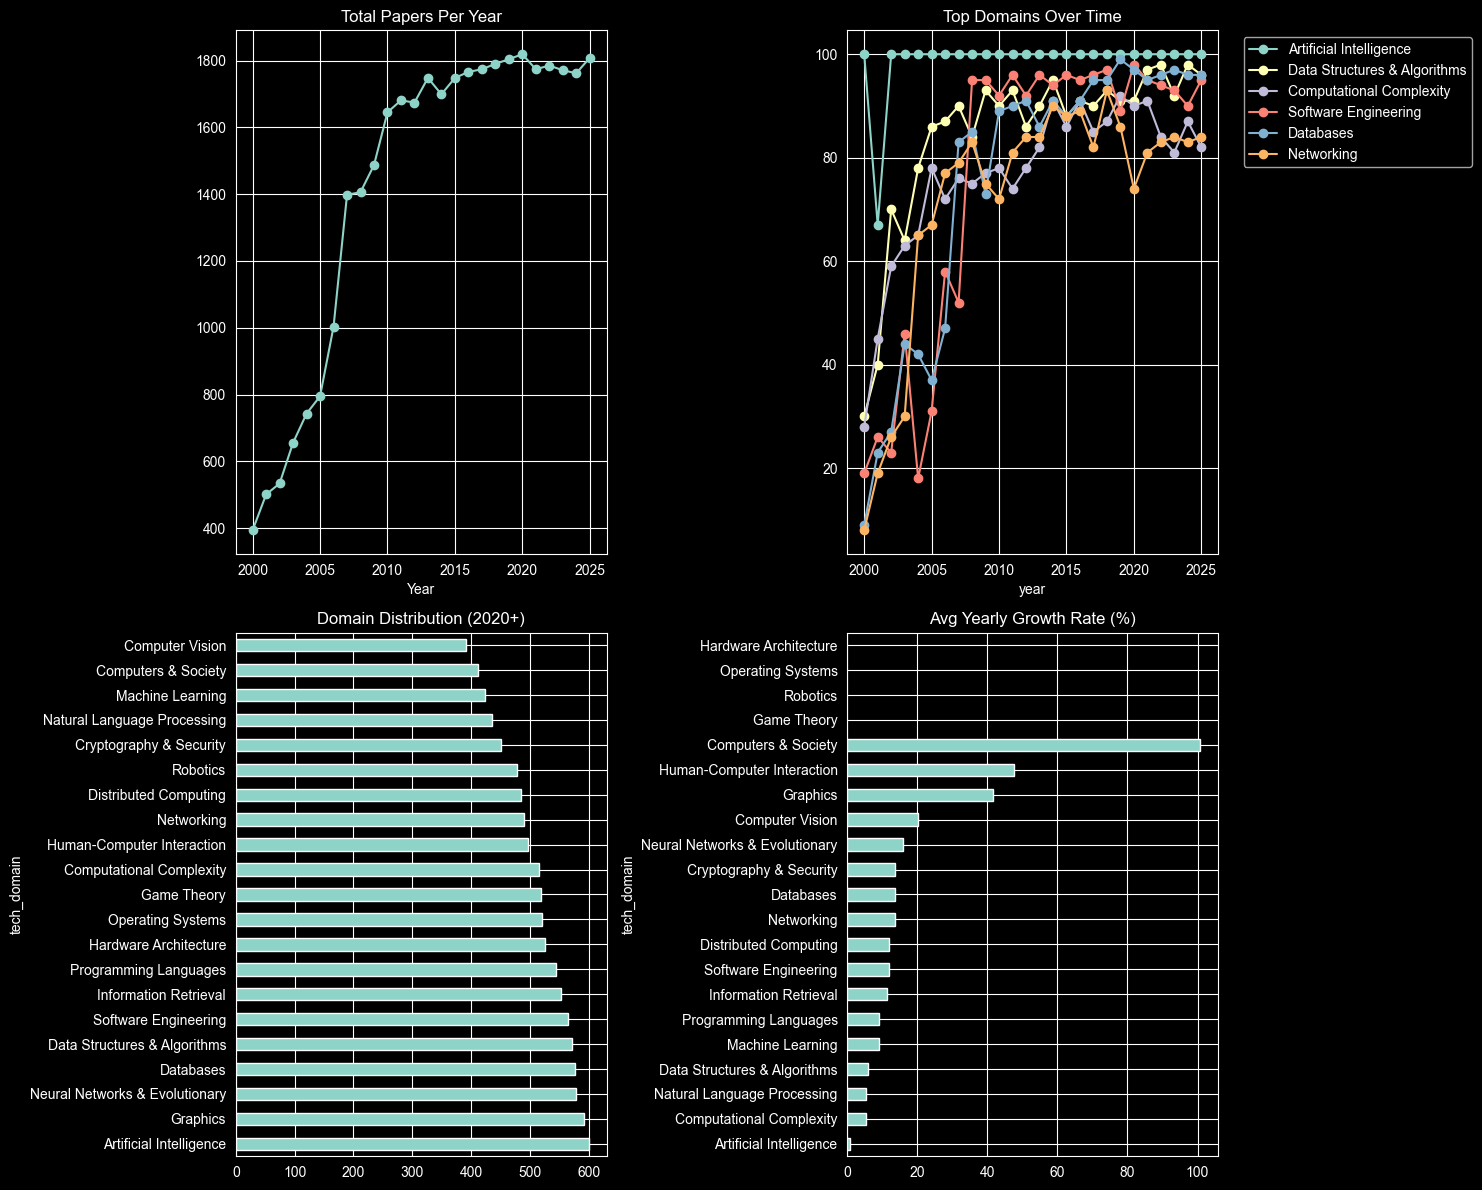

Saved: /Users/kethandosapati/Developer/personal/analysis_output/temporal_analysis.png


In [13]:
# temporal: papers per year, domain over time, growth rates → save temporal_analysis.png
import matplotlib.pyplot as plt

yearly_counts = df.groupby("year").size()
domain_year = df.groupby(["year", "tech_domain"]).size().unstack(fill_value=0)
growth_rates = domain_year.pct_change().mean() * 100
top_domains = df["tech_domain"].value_counts().head(6).index
recent_dist = df[df["year"] >= 2020]["tech_domain"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
yearly_counts.plot(ax=axes[0, 0], marker="o")
axes[0, 0].set_title("Total Papers Per Year")
axes[0, 0].set_xlabel("Year")
domain_year[top_domains].plot(ax=axes[0, 1], marker="o")
axes[0, 1].set_title("Top Domains Over Time")
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
recent_dist.plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Domain Distribution (2020+)")
growth_rates.sort_values().plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Avg Yearly Growth Rate (%)")
plt.tight_layout()
plt.savefig(output_dir / "temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", output_dir / "temporal_analysis.png")

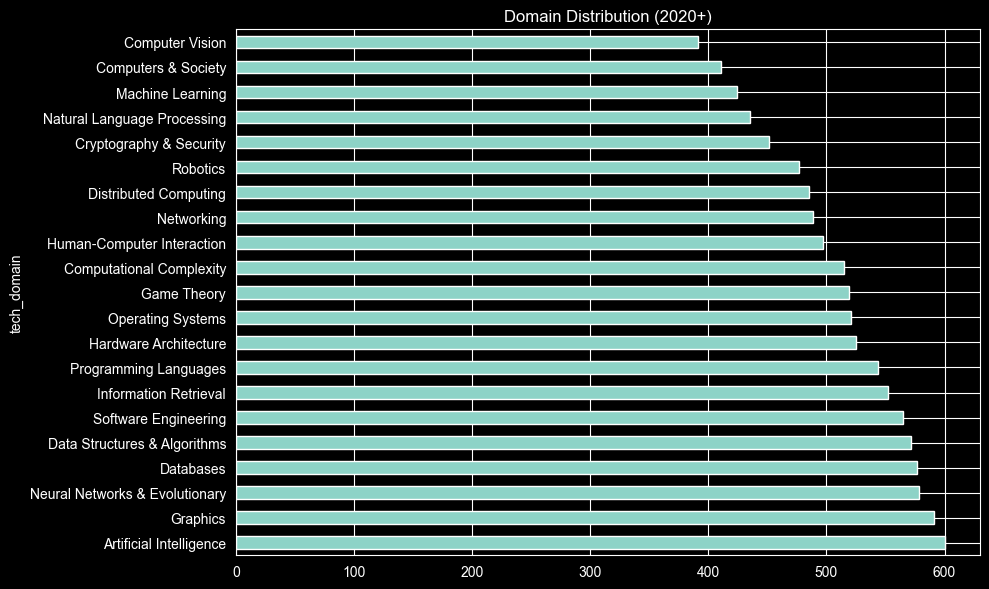

Saved: /Users/kethandosapati/Developer/personal/analysis_output/domain_distribution.png


In [11]:
# domain distribution (2020+) → save domain_distribution.png
recent = df[df["year"] >= 2020]["tech_domain"].value_counts()
plt.figure(figsize=(10, 6))
recent.plot(kind="barh")
plt.title("Domain Distribution (2020+)")
plt.tight_layout()
plt.savefig(output_dir / "domain_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", output_dir / "domain_distribution.png")

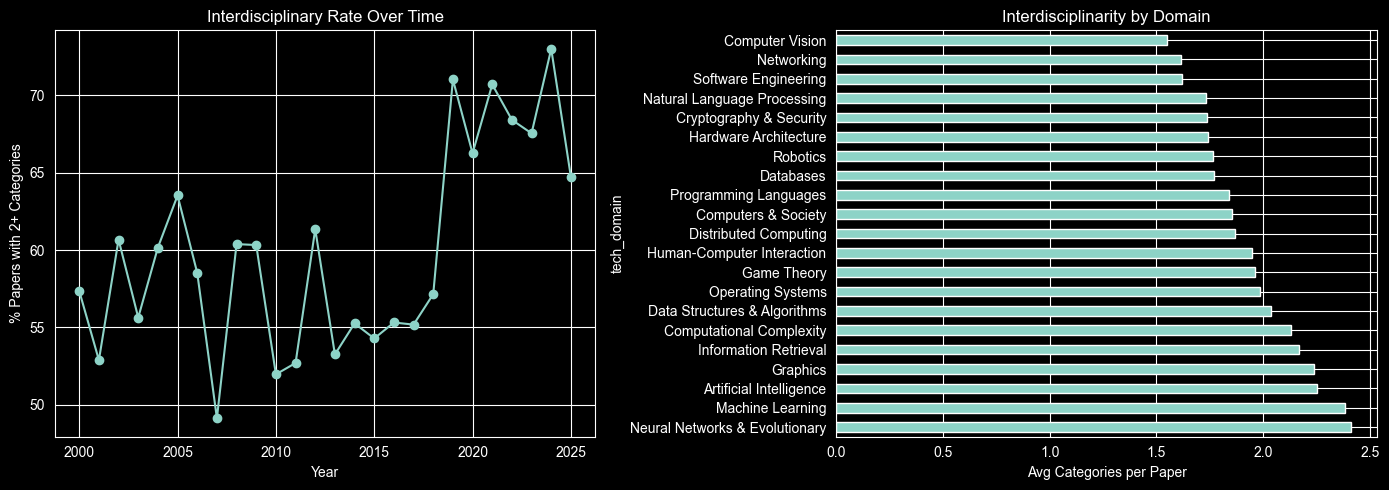

Saved: /Users/kethandosapati/Developer/personal/analysis_output/interdisciplinary_analysis.png


In [10]:
# interdisciplinary: how many categories per paper → save interdisciplinary_analysis.png
df["category_count"] = df["all_categories"].apply(lambda x: len(str(x).split(", ")))
yearly_multi = df.groupby("year")["category_count"].apply(lambda x: (x > 1).mean() * 100)
domain_inter = df.groupby("tech_domain")["category_count"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yearly_multi.plot(ax=axes[0], marker="o")
axes[0].set_title("Interdisciplinary Rate Over Time")
axes[0].set_ylabel("% Papers with 2+ Categories")
axes[0].set_xlabel("Year")
domain_inter.plot(kind="barh", ax=axes[1])
axes[1].set_title("Interdisciplinarity by Domain")
axes[1].set_xlabel("Avg Categories per Paper")
plt.tight_layout()
plt.savefig(output_dir / "interdisciplinary_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", output_dir / "interdisciplinary_analysis.png")

In [14]:
# raw TF-IDF: top keywords from title + abstract (no function)
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

df["text"] = df["title"] + " " + df["abstract"].fillna("")
vec = TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 2), min_df=5)
X = vec.fit_transform(df["text"])
names = vec.get_feature_names_out()
mean_tfidf = np.asarray(X.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:][::-1]
print("Top 20 TF-IDF keywords:", [names[i] for i in top_idx])

Top 20 TF-IDF keywords: ['data', 'based', 'model', 'algorithm', 'time', 'problem', 'learning', 'paper', 'using', 'network', 'systems', 'information', 'performance', 'approach', 'models', 'results', 'method', 'new', 'networks', 'algorithms']


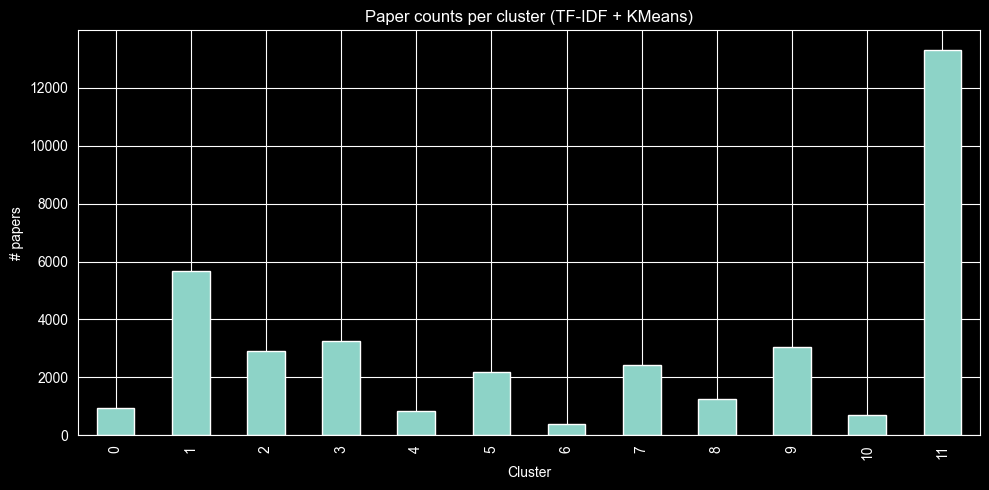

Saved: /Users/kethandosapati/Developer/personal/analysis_output/semantic_clusters.png


In [15]:
# simple clusters from TF-IDF (no embeddings): KMeans on X from previous cell → save semantic_clusters.png
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)
cluster_sizes = df["cluster"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
cluster_sizes.plot(kind="bar")
plt.title("Paper counts per cluster (TF-IDF + KMeans)")
plt.xlabel("Cluster")
plt.ylabel("# papers")
plt.tight_layout()
plt.savefig(output_dir / "semantic_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", output_dir / "semantic_clusters.png")